In [41]:
# Autorelaode all modules when they change
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Establishing TC max wind speed distributions

In [42]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append('../src')

from preprocessing.tropical_cyclone import aggregate_tc_data, get_stormfilenames


In [3]:
get_stormfilenames(2010, basin='al')

['bal012010.dat.gz',
 'bal022010.dat.gz',
 'bal032010.dat.gz',
 'bal042010.dat.gz',
 'bal052010.dat.gz',
 'bal062010.dat.gz',
 'bal072010.dat.gz',
 'bal082010.dat.gz',
 'bal092010.dat.gz',
 'bal102010.dat.gz',
 'bal112010.dat.gz',
 'bal122010.dat.gz',
 'bal132010.dat.gz',
 'bal142010.dat.gz',
 'bal152010.dat.gz',
 'bal162010.dat.gz',
 'bal172010.dat.gz',
 'bal182010.dat.gz',
 'bal192010.dat.gz',
 'bal202010.dat.gz',
 'bal212010.dat.gz']

In [14]:
aggregate_tc_data(np.arange(1900,1950), basin='al')

Fetching file lists for 50 year(s)...
Found 435 file(s) in total. Starting download...


Downloading: 100%|██████████| 435/435 [03:17<00:00,  2.20file/s]


All files downloaded successfully.


In [40]:
from probabilistic import load_historical_tracks, get_tc_origin

In [43]:
track_data, failed_files = load_historical_tracks("/Users/wirths/Documents/Private/NatCat/data/raw")

if failed_files:
    print(f"{len(failed_files)} file(s) failed to load:")
    for path, err in failed_files:
        print(f"  {os.path.basename(path)}: {type(err).__name__}: {err}")
else:
    print("All files loaded successfully.")

print(f"\nLoaded {len(track_data)} tracks.")

55 file(s) failed to load:
  bal011977.dat: ValueError: Quality check failed: Missing values in critical columns: {'max_wind_speed_kt': 1}
  bal081974.dat: ValueError: Quality check failed: Missing values in critical columns: {'max_wind_speed_kt': 1}
  bal181975.dat: ValueError: Quality check failed: Missing values in critical columns: {'max_wind_speed_kt': 1}
  bal051981.dat: ValueError: Quality check failed: Missing values in critical columns: {'max_wind_speed_kt': 1}
  bal101971.dat: ValueError: Quality check failed: Missing values in critical columns: {'max_wind_speed_kt': 1}
  bal041986.dat: ValueError: Quality check failed: Missing values in critical columns: {'max_wind_speed_kt': 1}
  bal141978.dat: ValueError: Quality check failed: Missing values in critical columns: {'max_wind_speed_kt': 1}
  bal111975.dat: ValueError: Quality check failed: Missing values in critical columns: {'max_wind_speed_kt': 1}
  bal091977.dat: ValueError: Quality check failed: Missing values in critical

In [56]:
tc_origib, historic_origin, kde = get_tc_origin(track_data, 10000)

In [57]:
tc_origib.head()

,storm_id,latitude,longitude
0,SYN_0,14.310952,-29.994415
1,SYN_1,22.387197,-49.547511
2,SYN_2,12.146349,-79.304613
3,SYN_3,27.784217,-90.070931
4,SYN_4,15.334112,-33.360455


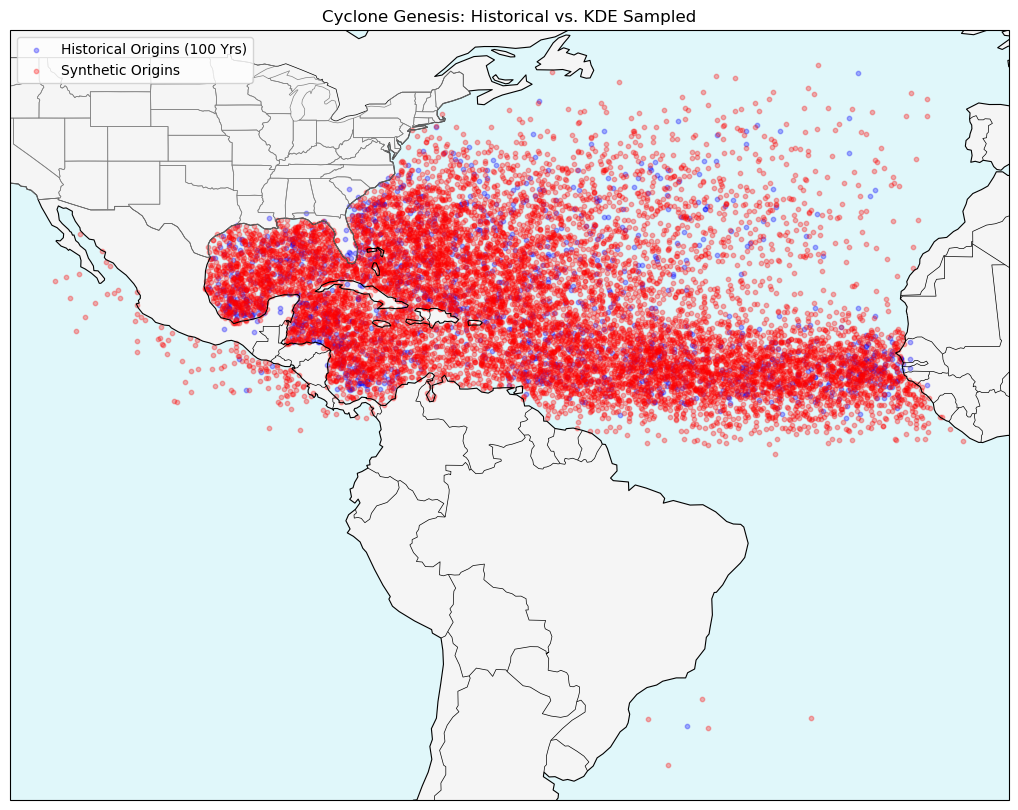

In [58]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(14, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
        
# Add Map Features
ax.add_feature(cfeature.LAND, facecolor='#f5f5f5')
ax.add_feature(cfeature.OCEAN, facecolor='#e0f7fa')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='gray')
#ax.set_extent(ax_extend, crs=ccrs.PlateCarree())
# Plot historical in blue
ax.scatter(historic_origin['longitude'], historic_origin['latitude'], 
            c='blue', alpha=0.3, s=10, label='Historical Origins (100 Yrs)')

# Plot synthetic in red
ax.scatter(tc_origib['longitude'], tc_origib['latitude'], 
            c='red', alpha=0.3, s=10, label='Synthetic Origins')

plt.title("Cyclone Genesis: Historical vs. KDE Sampled")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)
plt.show()